Name : Nisha Yuvraj Pragane | DIV:SEDA | Roll no :13 | PRN : 1252090013 | BATCH :B1
A retail company wants to group customers based on Annual Income and Spending Score for
targeted marketing. Dataset: Mall Customer Segmentation
(Kaggle): https://www.kaggle.com/datasets/shwetabh123/mall-customers
a. Preprocess data (missing values, encoding, scaling)
b. Apply Hierarchical Clustering and plot dendrography
c. Visualize clusters (Income vs Spending Score
d. Interpret and describe each customer segment

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

Load Dataset

In [ ]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Data Preprocessing

In [ ]:
df = df.dropna()

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

Elbow Method

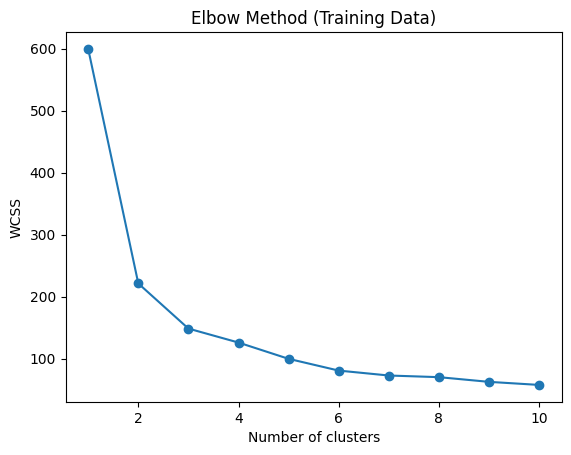

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method (Training Data)")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)
y_train = kmeans.predict(X_train)
y_test = kmeans.predict(X_test)

Silhoueete Score

In [ ]:
train_score = silhouette_score(X_train, y_train)
test_score = silhouette_score(X_test, y_test)
print("Train Silhouette Score:", train_score)
print("Test Silhouette Score:", test_score)

Train Silhouette Score: 0.5678057687378739
Test Silhouette Score: 0.5755796052349909


Visualization

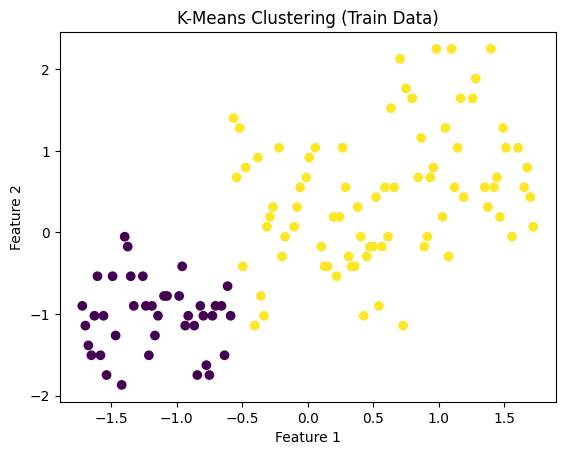

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis')
plt.title("K-Means Clustering (Train Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

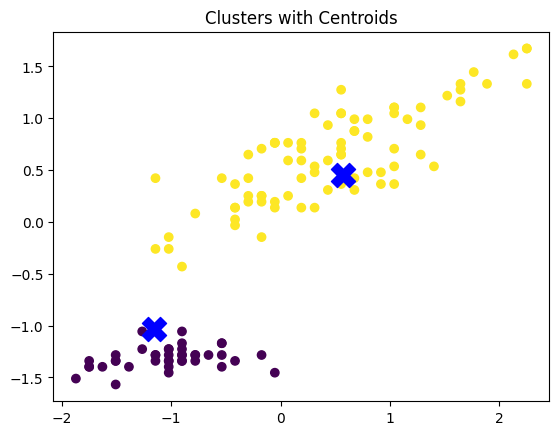

In [ ]:
centroids = kmeans.cluster_centers_

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='blue', marker='X')
plt.title("Clusters with Centroids")
plt.show()